In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


In [74]:
multirun_dir = 'multirun/2024-12-19/17-43-48'

# # create df of all results
# metric,value,std,category
# maximize,True,,config
# min_group_size,2,,config
# max_group_size,2,,config
# balance,0.99,,config
# theoretical_optimal_cost,391.94964595357305,,optimization
# gap_to_optimal_percent,0.11212143411773504,,optimization
# number_of_groups,98.0,,basic
# group_size_mean,2.0,0.0,basic
# group_size_min,2.0,,basic
# group_size_max,2.0,,basic
# within_group_variance,0.49875336425330913,0.3530124913662726,skill_diversity
# between_group_variance,0.0012466357466908958,0.0004619062262755038,skill_diversity
# sensitive_attr_0_population_mean,0.5,,fairness
# sensitive_attr_0_group_ratio_mean,0.5,0.0,fairness

df_rows = {
        'n_pairs': [],
        'balance': [],
        'seed': [],
        'convergence_time': [],
        'min_group_size': [],
        'max_group_size': [],
        'theoretical_optimal_cost': [],
        'gap_to_optimal_percent': [],
        'number_of_groups': [],
        'group_size_mean': [],
        'group_size_min': [],
        'group_size_max': [],
        'mean_within_group_variance': [],
        'std_within_group_variance': [],
        'mean_between_group_variance': [],
        'std_between_group_variance': [],
        'sensitive_attr_0_population_mean': [],
        'sensitive_attr_0_group_ratio_mean': [],
        'sensitive_attr_0_group_ratio_std': []
        }

# convergence time == 'cumulative time' column of last row in loss_curve.csv where improvement is True
# 26,195.51018638951052,195.51018638951052,0.3777174949645996,9.776551008224487,True 


for root, dirs, files in os.walk(multirun_dir):
    
    root_info_added = False
    for file in files:
        if ('n_pairs' in root) and ('balance' in root) and ('seed' in root):
            if file.endswith('.csv'):
                if file == 'loss_curve.csv':
                    loss_curve = pd.read_csv(os.path.join(root, file))
                    last_row = loss_curve.iloc[-1]
                    convergence_time = last_row['cumulative_time']
                    df_rows['convergence_time'].append(convergence_time)
                
                if file == 'stats.csv':
                    stats = pd.read_csv(os.path.join(root, file))
                    df_rows['min_group_size'].append(stats[stats['metric'] == 'min_group_size']['value'].values[0])
                    df_rows['max_group_size'].append(stats[stats['metric'] == 'max_group_size']['value'].values[0])
                    df_rows['theoretical_optimal_cost'].append(stats[stats['metric'] == 'theoretical_optimal_cost']['value'].values[0])
                    df_rows['gap_to_optimal_percent'].append(stats[stats['metric'] == 'gap_to_optimal_percent']['value'].values[0])
                    df_rows['number_of_groups'].append(stats[stats['metric'] == 'number_of_groups']['value'].values[0])
                    df_rows['group_size_mean'].append(stats[stats['metric'] == 'group_size_mean']['value'].values[0])
                    df_rows['group_size_min'].append(stats[stats['metric'] == 'group_size_min']['value'].values[0])
                    df_rows['group_size_max'].append(stats[stats['metric'] == 'group_size_max']['value'].values[0])
                    df_rows['mean_within_group_variance'].append(stats[stats['metric'] == 'within_group_variance']['value'].values[0])
                    df_rows['std_within_group_variance'].append(stats[stats['metric'] == 'within_group_variance']['std'].values[0])
                    df_rows['mean_between_group_variance'].append(stats[stats['metric'] == 'between_group_variance']['value'].values[0])
                    df_rows['std_between_group_variance'].append(stats[stats['metric'] == 'between_group_variance']['std'].values[0])
                    df_rows['sensitive_attr_0_population_mean'].append(stats[stats['metric'] == 'sensitive_attr_0_population_mean']['value'].values[0])
                    df_rows['sensitive_attr_0_group_ratio_mean'].append(stats[stats['metric'] == 'sensitive_attr_0_group_ratio_mean']['value'].values[0])
                    df_rows['sensitive_attr_0_group_ratio_std'].append(stats[stats['metric'] == 'sensitive_attr_0_group_ratio_mean']['std'].values[0])

                if not root_info_added:
                    n_pairs = int(root.split('n_pairs_')[1].split('/')[0])
                    balance = float(root.split('balance_')[1].split('/')[0])
                    seed = int(root.split('seed_')[1].split('/')[0])
                    df_rows['n_pairs'].append(n_pairs)
                    df_rows['balance'].append(balance)
                    df_rows['seed'].append(seed)
                    root_info_added = True


In [75]:
df = pd.DataFrame(df_rows)
df = df.astype(float)
df_mean = df.groupby(['n_pairs', 'balance']).mean().reset_index()
df_err = df.groupby(['n_pairs', 'balance']).std().reset_index()

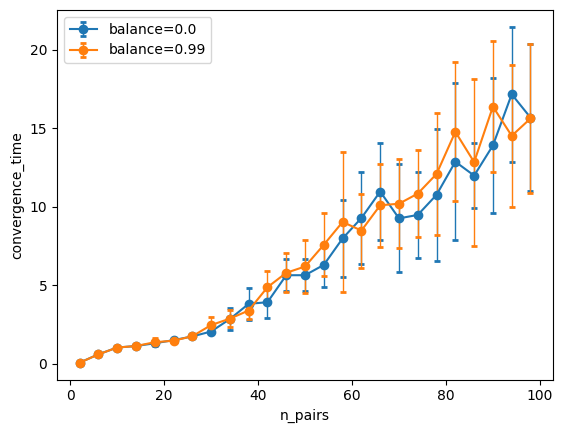

In [76]:
# plot convergence time vs n_pairs, with error bars
plt.figure()
for balance in df_mean['balance'].unique():
    df_mean_subset = df_mean[df_mean['balance'] == balance]
    df_err_subset = df_err[df_err['balance'] == balance]
    plt.errorbar(df_mean_subset['n_pairs'], df_mean_subset['convergence_time'], yerr=df_err_subset['convergence_time'], label=f'balance={balance}', fmt='-o', capsize=2, capthick=2, elinewidth=1)

plt.xlabel('n_pairs')
plt.ylabel('convergence_time')
plt.legend()

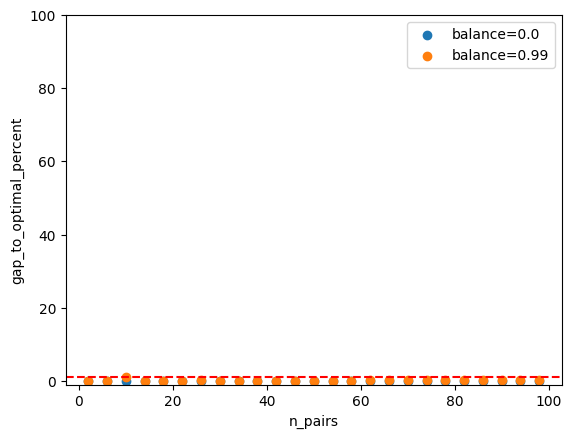

In [84]:
# plot the gap to optimal percent vs n_pairs, with error bars
plt.figure()
for balance in df_mean['balance'].unique():
    df_mean_subset = df_mean[df_mean['balance'] == balance]
    df_err_subset = df_err[df_err['balance'] == balance]
    plt.scatter(df_mean_subset['n_pairs'], df_mean_subset['gap_to_optimal_percent'], label=f'balance={balance}')

plt.xlabel('n_pairs')
plt.ylabel('gap_to_optimal_percent')
plt.legend()
plt.ylim(-1, 100)

# hline at 1% gap
plt.axhline(y=1, color='r', linestyle='--')


In [82]:
df

,n_pairs,balance,seed,convergence_time,min_group_size,max_group_size,theoretical_optimal_cost,gap_to_optimal_percent,number_of_groups,group_size_mean,group_size_min,group_size_max,mean_within_group_variance,std_within_group_variance,mean_between_group_variance,std_between_group_variance,sensitive_attr_0_population_mean,sensitive_attr_0_group_ratio_mean,sensitive_attr_0_group_ratio_std
0,50.0,0.99,4.0,5.989060,2.0,2.0,199.901312,0.055220,50.0,2.0,2.0,2.0,0.498957,0.352179,0.001043,1.120035e-04,0.5,0.5,0.000000
1,50.0,0.99,6.0,6.590842,2.0,2.0,199.901312,0.015786,50.0,2.0,2.0,2.0,0.499349,0.352922,0.000651,1.732090e-05,0.5,0.5,0.000000
2,50.0,0.99,10.0,6.045355,2.0,2.0,199.901312,0.007893,50.0,2.0,2.0,2.0,0.499428,0.353004,0.000572,1.960994e-05,0.5,0.5,0.000000
3,50.0,0.99,2.0,5.998428,2.0,2.0,199.901312,0.015786,50.0,2.0,2.0,2.0,0.499349,0.353034,0.000651,7.134832e-05,0.5,0.5,0.000000
4,50.0,0.99,1.0,5.246611,2.0,2.0,199.901312,0.394654,50.0,2.0,2.0,2.0,0.495572,0.350422,0.004428,8.673617e-19,0.5,0.5,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,66.0,0.00,3.0,13.084776,2.0,2.0,264.000000,0.002575,66.0,2.0,2.0,2.0,0.499974,0.353519,0.000026,1.238029e-05,0.5,0.5,0.476731
496,66.0,0.00,9.0,7.787448,2.0,2.0,264.000000,0.010298,66.0,2.0,2.0,2.0,0.499897,0.353493,0.000103,1.401129e-05,0.5,0.5,0.435194
497,66.0,0.00,5.0,12.617449,2.0,2.0,264.000000,0.005149,66.0,2.0,2.0,2.0,0.499949,0.353540,0.000051,9.271599e-07,0.5,0.5,0.452267
498,66.0,0.00,8.0,12.642675,2.0,2.0,264.000000,0.004291,66.0,2.0,2.0,2.0,0.499957,0.353537,0.000043,2.433472e-05,0.5,0.5,0.460566
